<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/Credit_Card_Default_Prediction_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Default Prediction Using Machine Learning

## Data Science Portfolio Project

This original, self-contained notebook builds an end-to-end model that predicts whether a borrower may experience serious delinquency within the next 24 months.

**Skills demonstrated:** business framing, synthetic data generation, data auditing, EDA, missing-value treatment, outlier capping, feature engineering, class-imbalance handling, logistic regression, random forest, gradient boosting, neural networks, cross-validation, threshold optimization, calibration, interpretability, subgroup diagnostics, model saving, and inference.

> Educational portfolio project only. The data is synthetic and the model must not be used for real lending decisions.

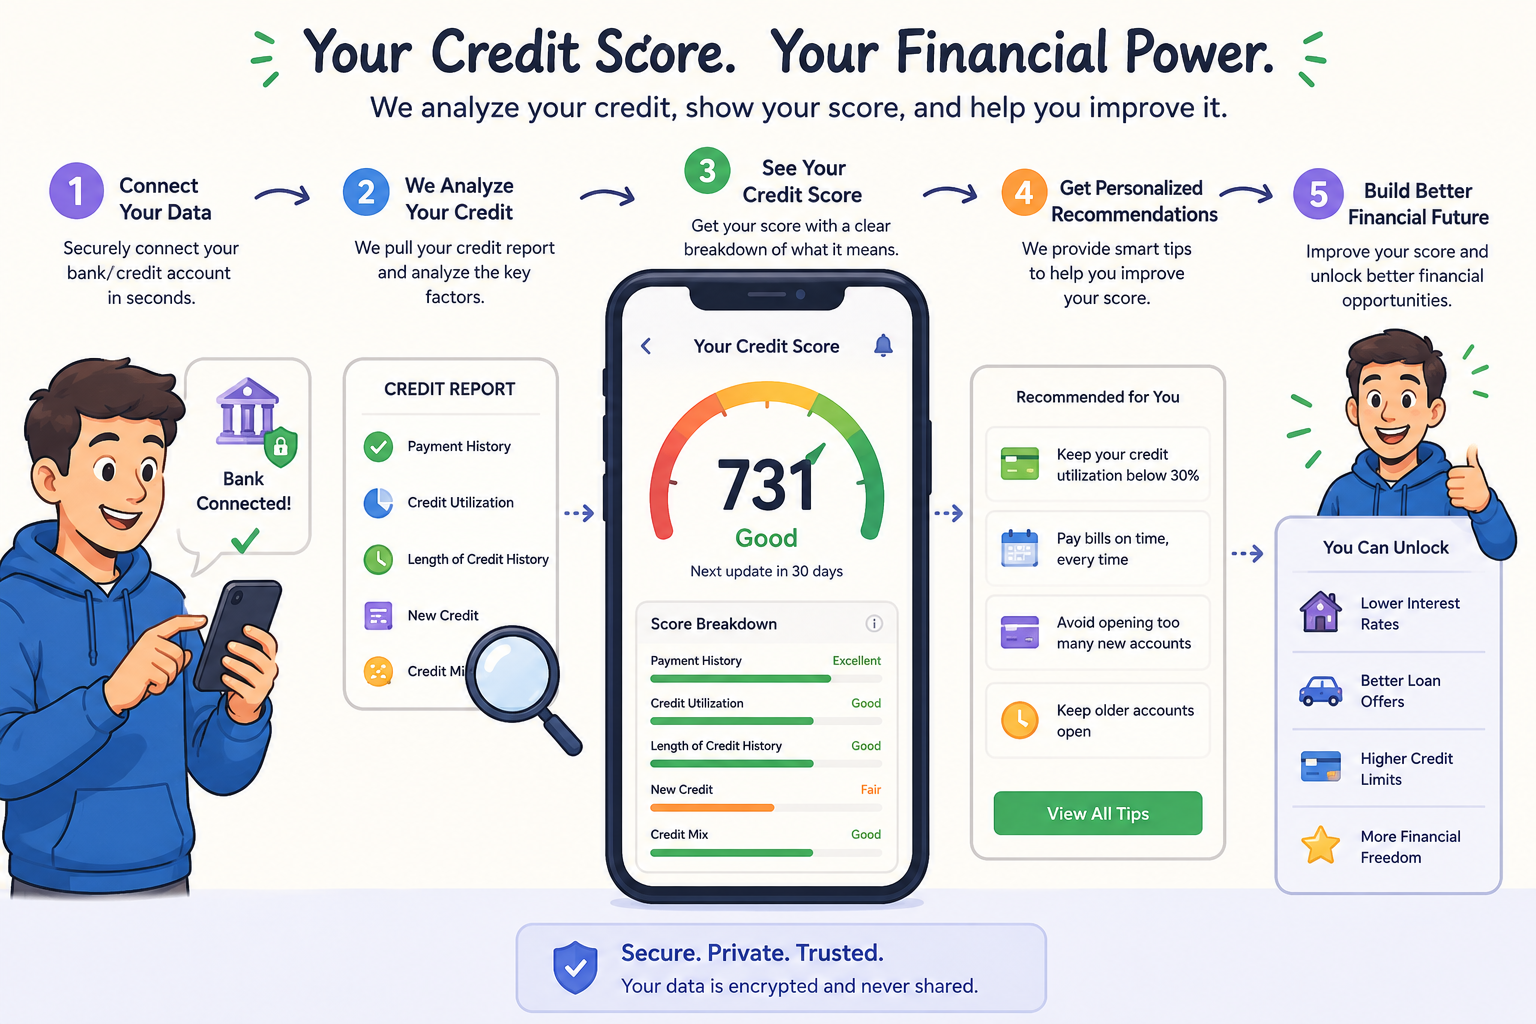

## 1. Business Problem

Credit default can create losses, collection costs, and customer hardship. A predictive model can estimate default risk early enough to support approved interventions such as reminders, hardship outreach, or manual review.

The target is `default_next_24m`, where `1` represents serious delinquency or default within the next two years.

## 2. Evaluation Strategy

Because defaults are usually uncommon, accuracy alone is insufficient. This notebook uses ROC-AUC, PR-AUC, precision, recall, F1 score, calibration, and a business-cost threshold.

In [ ]:
# Uncomment in a fresh environment if needed.
# !pip install numpy pandas matplotlib scikit-learn joblib

In [ ]:
import json, random, warnings
from pathlib import Path
from typing import Dict, Tuple

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler

warnings.filterwarnings('ignore')
SEED=42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option('display.max_columns',100)
print('Environment ready')

Environment ready


## 3. Create an Original Synthetic Credit Dataset

The generated features resemble common consumer-credit variables while avoiding proprietary data.

In [ ]:
def sigmoid(x):
    return 1.0/(1.0+np.exp(-x))

def generate_credit_data(n_samples=12000, seed=42):
    rng=np.random.default_rng(seed)
    age=np.clip(rng.normal(46,13,n_samples),18,90).round()
    monthly_income=np.clip(np.exp(rng.normal(np.log(5200),0.65,n_samples)),500,40000)
    dependents=np.clip(rng.poisson(1.3,n_samples),0,8)
    credit_history_years=np.clip((age-18)*rng.uniform(0.25,0.90,n_samples),0.5,55)
    open_credit_lines=np.clip(rng.poisson(7+0.08*credit_history_years),1,30)
    real_estate_loans=np.clip(rng.poisson(0.7+0.018*np.maximum(age-30,0)),0,8)
    utilization=np.clip(rng.beta(1.7,3.2,n_samples)+rng.normal(0,0.06,n_samples),0,1.6)
    debt_ratio=np.clip(rng.gamma(2.0,0.18,n_samples)+0.045*dependents,0.01,2.5)
    inquiries_6m=np.clip(rng.poisson(1.2+0.9*(utilization>0.75)),0,15)
    late_30_59=rng.poisson(0.08+0.9*(utilization>0.80)+0.35*(debt_ratio>0.65))
    late_60_89=rng.poisson(0.03+0.45*(utilization>0.90)+0.20*(late_30_59>0))
    late_90_plus=rng.poisson(0.015+0.30*(utilization>1.00)+0.28*(late_60_89>0))
    payment_ratio_6m=np.clip(1.05-0.45*utilization-0.22*debt_ratio-0.08*late_30_59+rng.normal(0,0.12,n_samples),0,1.4)
    logit=(-4.1+2.5*utilization+1.15*debt_ratio+0.55*late_30_59+0.85*late_60_89+
           1.10*late_90_plus+0.10*inquiries_6m-1.10*payment_ratio_6m-0.012*(age-45)-
           0.000035*(monthly_income-5000)-0.012*credit_history_years+0.08*dependents+
           0.50*((utilization>0.85)&(debt_ratio>0.70)))
    target=rng.binomial(1,sigmoid(logit))
    df=pd.DataFrame({
        'borrower_id':np.arange(100000,100000+n_samples),'age':age.astype(int),
        'monthly_income':monthly_income.round(2),'dependents':dependents.astype(float),
        'revolving_utilization':utilization.round(4),'debt_ratio':debt_ratio.round(4),
        'open_credit_lines':open_credit_lines.astype(int),'real_estate_loans':real_estate_loans.astype(int),
        'late_30_59':late_30_59.astype(int),'late_60_89':late_60_89.astype(int),
        'late_90_plus':late_90_plus.astype(int),'payment_ratio_6m':payment_ratio_6m.round(4),
        'credit_history_years':credit_history_years.round(2),'inquiries_6m':inquiries_6m.astype(int),
        'default_next_24m':target.astype(int)})
    df.loc[rng.choice(n_samples,int(n_samples*0.07),replace=False),'monthly_income']=np.nan
    df.loc[rng.choice(n_samples,int(n_samples*0.025),replace=False),'dependents']=np.nan
    rows=rng.choice(n_samples,max(10,int(n_samples*0.004)),replace=False)
    df.loc[rows,'revolving_utilization']*=rng.uniform(3,7,len(rows))
    return df

df=generate_credit_data()
print(df.shape)
df.head()

(12000, 15)


,borrower_id,age,monthly_income,dependents,revolving_utilization,debt_ratio,open_credit_lines,real_estate_loans,late_30_59,late_60_89,late_90_plus,payment_ratio_6m,credit_history_years,inquiries_6m,default_next_24m
0,100000,50,4251.61,0.0,0.6997,0.2741,9,1,0,0,0,0.5538,24.57,0,0
1,100001,32,5407.64,2.0,0.3482,0.2383,12,1,0,0,0,0.9241,11.10,3,0
2,100002,56,2321.39,2.0,0.2439,0.2038,10,1,0,0,0,0.9544,22.33,2,0
3,100003,58,2109.85,2.0,0.0222,1.1199,4,1,0,0,0,1.0342,19.50,0,0
4,100004,21,5854.16,0.0,0.0729,0.3636,4,1,0,0,0,0.9576,1.24,1,0


In [ ]:
df.to_csv('synthetic_credit_default_data.csv',index=False)
print('Event rate: {:.2%}'.format(df.default_next_24m.mean()))

Event rate: 4.83%


## 4. Data Quality Audit

In [ ]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),
                    'missing_pct':df.isna().mean()*100,'unique':df.nunique()})
audit

,dtype,missing,missing_pct,unique
borrower_id,int64,0,0.0,12000
age,int64,0,0.0,73
monthly_income,float64,840,7.0,11098
dependents,float64,300,2.5,8
revolving_utilization,float64,0,0.0,5924
debt_ratio,float64,0,0.0,6376
open_credit_lines,int64,0,0.0,21
real_estate_loans,int64,0,0.0,8
late_30_59,int64,0,0.0,6
late_60_89,int64,0,0.0,4


In [ ]:
print('Duplicate IDs:',df.borrower_id.duplicated().sum())
print(df.default_next_24m.value_counts())

Duplicate IDs: 0
default_next_24m
0    11420
1      580
Name: count, dtype: int64


## 5. Exploratory Data Analysis

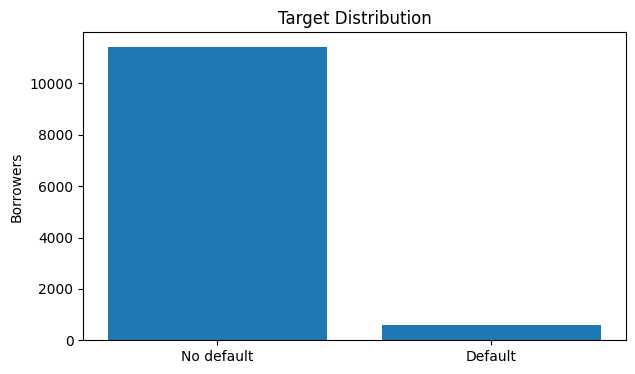

In [ ]:
counts=df.default_next_24m.value_counts().sort_index()
plt.figure(figsize=(7,4)); plt.bar(['No default','Default'],counts.values)
plt.title('Target Distribution'); plt.ylabel('Borrowers'); plt.show()

In [ ]:
features=[c for c in df.columns if c not in ['borrower_id','default_next_24m']]
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,12000.0,45.928917,12.863222,18.0000,37.000000,46.00000,54.0000,90.000000
monthly_income,11160.0,6515.176119,4608.287461,500.0000,3407.072500,5248.07500,8161.4525,40000.000000
dependents,11700.0,1.302479,1.144210,0.0000,0.000000,1.00000,2.0000,7.000000
revolving_utilization,12000.0,0.351462,0.231054,0.0000,0.189100,0.32735,0.4872,5.678523
debt_ratio,12000.0,0.418663,0.262607,0.0100,0.229400,0.35960,0.5471,2.224400
open_credit_lines,12000.0,8.302500,2.979189,1.0000,6.000000,8.00000,10.0000,21.000000
real_estate_loans,12000.0,0.977417,1.012172,0.0000,0.000000,1.00000,2.0000,7.000000
late_30_59,12000.0,0.152750,0.429456,0.0000,0.000000,0.00000,0.0000,5.000000
late_60_89,12000.0,0.060167,0.255706,0.0000,0.000000,0.00000,0.0000,3.000000
late_90_plus,12000.0,0.032500,0.190910,0.0000,0.000000,0.00000,0.0000,3.000000


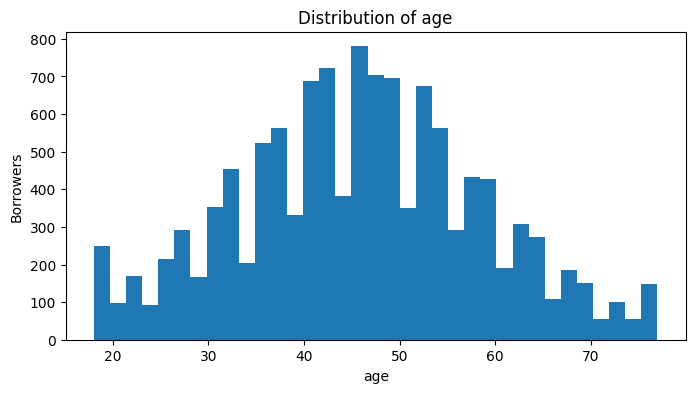

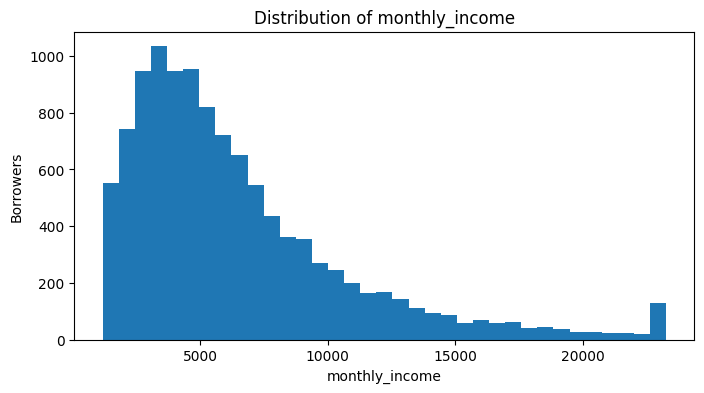

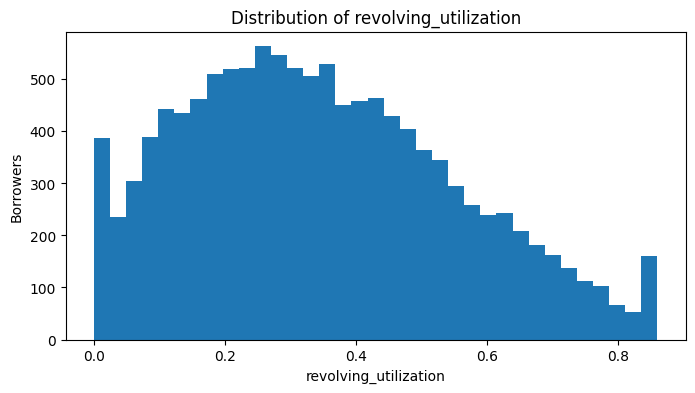

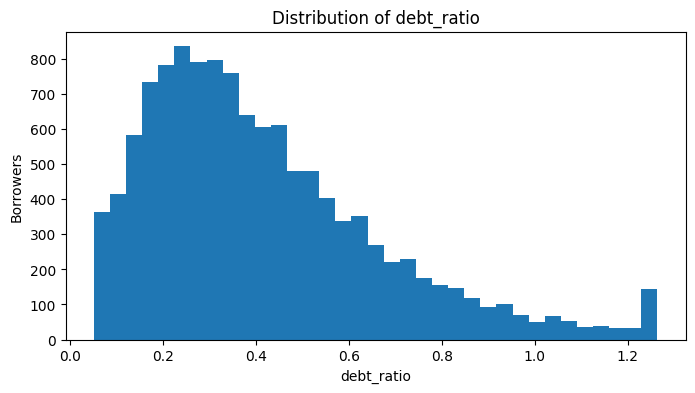

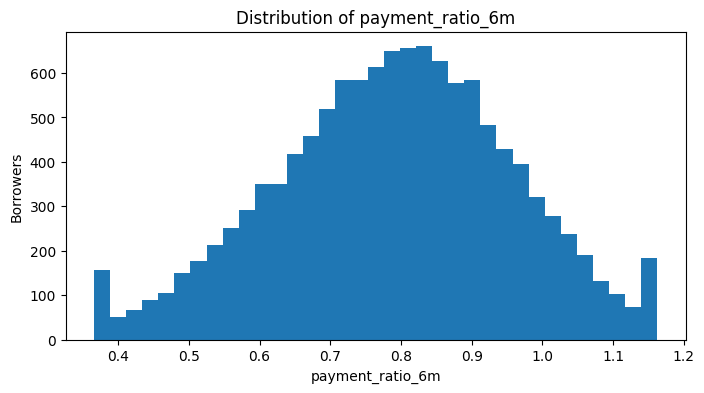

In [ ]:
for feature in ['age','monthly_income','revolving_utilization','debt_ratio','payment_ratio_6m']:
    values=df[feature].dropna(); lo,hi=values.quantile([0.01,0.99])
    plt.figure(figsize=(8,4)); plt.hist(values.clip(lo,hi),bins=35)
    plt.title('Distribution of '+feature); plt.xlabel(feature); plt.ylabel('Borrowers'); plt.show()

## 6. Default Rate by Risk Driver

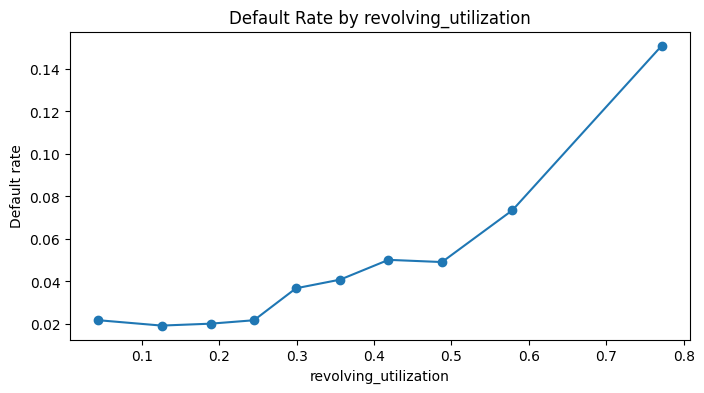

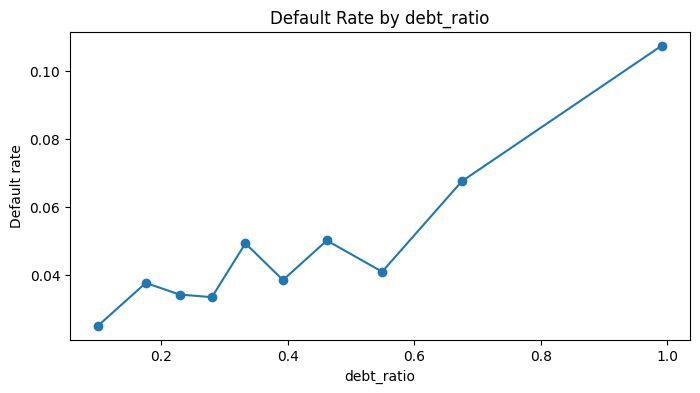

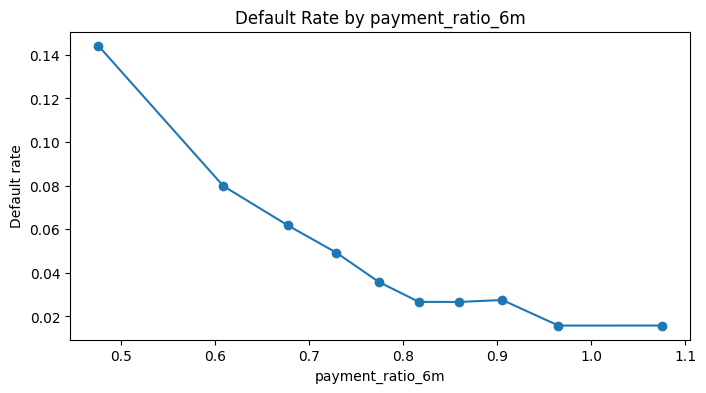

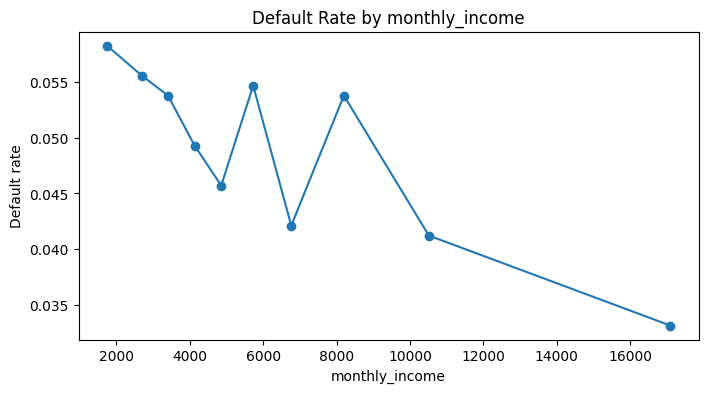

In [ ]:
def rate_by_quantile(data,feature,bins=10):
    t=data[[feature,'default_next_24m']].dropna().copy()
    t['bin']=pd.qcut(t[feature],q=bins,duplicates='drop')
    return t.groupby('bin',observed=False).agg(borrowers=('default_next_24m','size'),
        default_rate=('default_next_24m','mean'),feature_mean=(feature,'mean')).reset_index()

for feature in ['revolving_utilization','debt_ratio','payment_ratio_6m','monthly_income']:
    r=rate_by_quantile(df,feature)
    plt.figure(figsize=(8,4)); plt.plot(r.feature_mean,r.default_rate,marker='o')
    plt.title('Default Rate by '+feature); plt.xlabel(feature); plt.ylabel('Default rate'); plt.show()

## 7. Stratified Train, Validation, and Test Split

In [ ]:
TARGET='default_next_24m'
X=df.drop(columns=[TARGET,'borrower_id']); y=df[TARGET]
X_train_full,X_test,y_train_full,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=SEED)
X_train,X_valid,y_train,y_valid=train_test_split(X_train_full,y_train_full,test_size=0.25,stratify=y_train_full,random_state=SEED)
pd.DataFrame({'rows':[len(X_train),len(X_valid),len(X_test)],
              'default_rate':[y_train.mean(),y_valid.mean(),y_test.mean()]},
             index=['train','validation','test'])

,rows,default_rate
train,7200,0.048333
validation,2400,0.048333
test,2400,0.048333


## 8. Outlier Treatment and Feature Engineering

Caps are learned from training data only to prevent leakage.

In [ ]:
cap_columns=['monthly_income','revolving_utilization','debt_ratio','payment_ratio_6m','credit_history_years']
cap_limits={c:(float(X_train[c].quantile(0.005)),float(X_train[c].quantile(0.995))) for c in cap_columns}

def engineer_features(data,limits):
    t=data.copy()
    for c,(lo,hi) in limits.items(): t[c]=t[c].clip(lo,hi)
    t['total_delinquencies']=t.late_30_59+t.late_60_89+t.late_90_plus
    t['has_severe_delinquency']=(t.late_90_plus>0).astype(int)
    t['credit_stress_index']=t.revolving_utilization*t.debt_ratio/t.payment_ratio_6m.clip(lower=0.05)
    t['debt_per_credit_line']=t.debt_ratio/t.open_credit_lines.clip(lower=1)
    t['income_per_dependent']=t.monthly_income/(t.dependents.fillna(0)+1)
    t['credit_line_density']=t.open_credit_lines/t.credit_history_years.clip(lower=0.5)
    return t

X_train_fe=engineer_features(X_train,cap_limits)
X_valid_fe=engineer_features(X_valid,cap_limits)
X_test_fe=engineer_features(X_test,cap_limits)
X_train_fe.head()

,age,monthly_income,dependents,revolving_utilization,debt_ratio,open_credit_lines,real_estate_loans,late_30_59,late_60_89,late_90_plus,payment_ratio_6m,credit_history_years,inquiries_6m,total_delinquencies,has_severe_delinquency,credit_stress_index,debt_per_credit_line,income_per_dependent,credit_line_density
7768,49,12655.83,1.0,0.5605,0.5144,7,0,0,0,0,0.6572,8.47,0,0,0,0.438712,0.073486,6327.915000,0.826446
5710,57,14796.37,2.0,0.3963,0.2387,9,0,0,0,0,0.6808,15.37,5,0,0,0.138949,0.026522,4932.123333,0.585556
6249,49,11818.12,0.0,0.8015,0.0796,5,3,1,0,0,0.7855,17.13,0,1,0,0.081221,0.015920,11818.120000,0.291886
2137,57,NaN,3.0,0.2839,0.6644,8,2,0,0,0,0.7089,25.60,1,0,0,0.266079,0.083050,NaN,0.312500
8384,43,12125.37,1.0,0.3466,0.5892,12,0,0,0,0,0.7670,16.58,2,0,0,0.266254,0.049100,6062.685000,0.723764


## 9. Class Imbalance

Class-weighted models increase the penalty for missing the minority default class.

In [ ]:
print(y_train.value_counts())
print('Imbalance ratio:',round((y_train==0).sum()/max((y_train==1).sum(),1),2))

default_next_24m
0    6852
1     348
Name: count, dtype: int64
Imbalance ratio: 19.69


## 10. Preprocessing and Candidate Models

In [ ]:
scaled=Pipeline([('imputer',SimpleImputer(strategy='median')),
                 ('power',PowerTransformer(method='yeo-johnson',standardize=False)),
                 ('scaler',StandardScaler())])
tree=Pipeline([('imputer',SimpleImputer(strategy='median'))])

models={
'Logistic Regression':Pipeline([('preprocess',clone(scaled)),('model',LogisticRegression(max_iter=2000,class_weight='balanced',random_state=SEED))]),
'Random Forest':Pipeline([('preprocess',clone(tree)),('model',RandomForestClassifier(n_estimators=350,max_depth=10,min_samples_leaf=8,class_weight='balanced_subsample',n_jobs=-1,random_state=SEED))]),
'Gradient Boosting':Pipeline([('preprocess',clone(tree)),('model',HistGradientBoostingClassifier(max_iter=250,learning_rate=0.06,max_leaf_nodes=20,l2_regularization=1.0,random_state=SEED))]),
'Neural Network':Pipeline([('preprocess',clone(scaled)),('model',MLPClassifier(hidden_layer_sizes=(64,32),alpha=0.001,max_iter=250,early_stopping=True,random_state=SEED))])}

In [ ]:
def evaluate(y_true,p,threshold=0.5):
    pred=(p>=threshold).astype(int)
    return {'roc_auc':roc_auc_score(y_true,p),'pr_auc':average_precision_score(y_true,p),
            'accuracy':accuracy_score(y_true,pred),'precision':precision_score(y_true,pred,zero_division=0),
            'recall':recall_score(y_true,pred,zero_division=0),'f1':f1_score(y_true,pred,zero_division=0)}

fitted={}; rows=[]
for name,m in models.items():
    print('Training',name); m.fit(X_train_fe,y_train); p=m.predict_proba(X_valid_fe)[:,1]
    r=evaluate(y_valid,p); r['model']=name; rows.append(r); fitted[name]=m
validation_results=pd.DataFrame(rows).set_index('model').sort_values('roc_auc',ascending=False)
validation_results

Training Logistic Regression
Training Random Forest
Training Gradient Boosting
Training Neural Network


,roc_auc,pr_auc,accuracy,precision,recall,f1
model,,,,,,
Logistic Regression,0.806061,0.251631,0.735000,0.128571,0.775862,0.220588
Random Forest,0.782909,0.210236,0.922917,0.214876,0.224138,0.219409
Neural Network,0.777259,0.218850,0.952500,0.571429,0.068966,0.123077
Gradient Boosting,0.766200,0.210821,0.952500,0.600000,0.051724,0.095238


## 11. ROC and Precision-Recall Curves

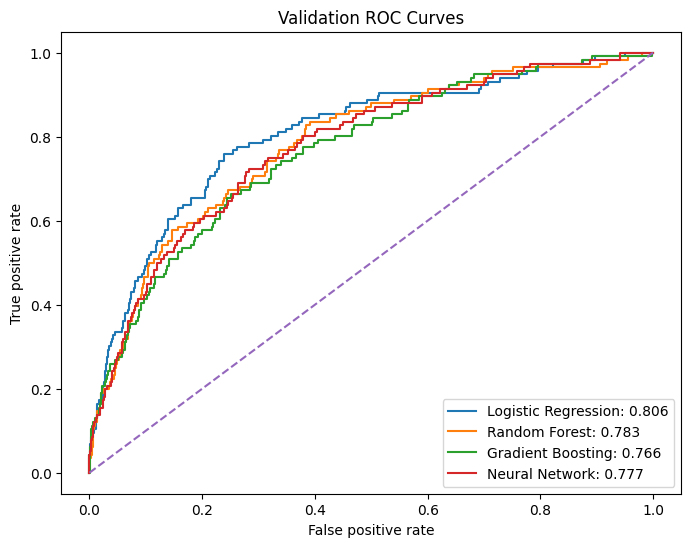

In [ ]:
plt.figure(figsize=(8,6))
for name,m in fitted.items():
    p=m.predict_proba(X_valid_fe)[:,1]; fpr,tpr,_=roc_curve(y_valid,p)
    plt.plot(fpr,tpr,label=f'{name}: {roc_auc_score(y_valid,p):.3f}')
plt.plot([0,1],[0,1],linestyle='--'); plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('Validation ROC Curves'); plt.legend(); plt.show()

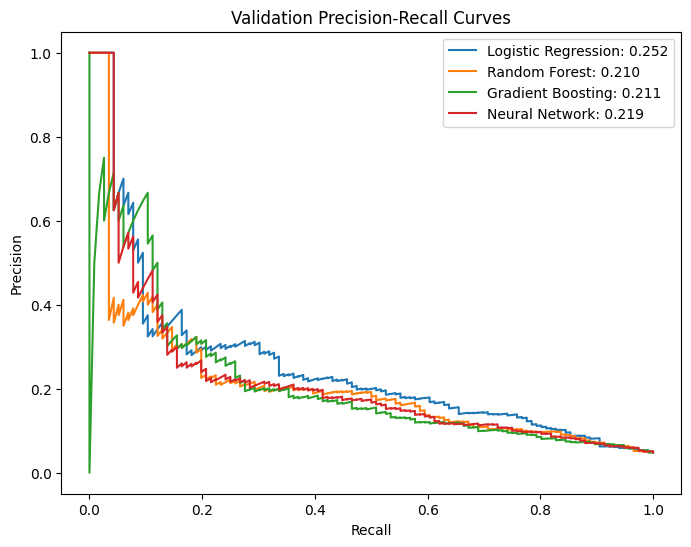

In [ ]:
plt.figure(figsize=(8,6))
for name,m in fitted.items():
    p=m.predict_proba(X_valid_fe)[:,1]; precision,recall,_=precision_recall_curve(y_valid,p)
    plt.plot(recall,precision,label=f'{name}: {average_precision_score(y_valid,p):.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Validation Precision-Recall Curves'); plt.legend(); plt.show()

## 12. Hyperparameter Tuning

In [ ]:
pipe=Pipeline([('preprocess',clone(tree)),('model',RandomForestClassifier(class_weight='balanced_subsample',n_jobs=-1,random_state=SEED))])
params={'model__n_estimators':[250,450],'model__max_depth':[8,12,None],
        'model__min_samples_leaf':[4,10],'model__max_features':['sqrt',0.7]}
cv=StratifiedKFold(n_splits=4,shuffle=True,random_state=SEED)
grid=GridSearchCV(pipe,params,scoring='roc_auc',cv=cv,n_jobs=-1)
grid.fit(X_train_fe,y_train)
print('Best CV ROC-AUC:',round(grid.best_score_,4)); grid.best_params_

Best CV ROC-AUC: 0.7239


{'model__max_depth': 8,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 10,
 'model__n_estimators': 450}

In [ ]:
best_model=grid.best_estimator_
valid_p=best_model.predict_proba(X_valid_fe)[:,1]
pd.Series(evaluate(y_valid,valid_p),name='Tuned Random Forest')

,Tuned Random Forest
roc_auc,0.787408
pr_auc,0.206128
accuracy,0.900417
precision,0.187817
recall,0.318966
f1,0.236422


## 13. Business-Cost Threshold Optimization

Illustrative costs: false negative = 8 units, false positive = 1 unit.

In [ ]:
def threshold_table(y_true,p,thresholds,fn_cost=8.0,fp_cost=1.0):
    rows=[]
    for t in thresholds:
        pred=(p>=t).astype(int); tn,fp,fn,tp=confusion_matrix(y_true,pred,labels=[0,1]).ravel()
        rows.append({'threshold':t,'tn':tn,'fp':fp,'fn':fn,'tp':tp,
                     'precision':precision_score(y_true,pred,zero_division=0),
                     'recall':recall_score(y_true,pred,zero_division=0),
                     'f1':f1_score(y_true,pred,zero_division=0),'cost':fn_cost*fn+fp_cost*fp})
    return pd.DataFrame(rows)

costs=threshold_table(y_valid,valid_p,np.linspace(0.05,0.90,86))
best_row=costs.loc[costs.cost.idxmin()]; best_threshold=float(best_row.threshold)
best_row

,37
threshold,0.420000
tn,1978.000000
fp,306.000000
fn,50.000000
tp,66.000000
precision,0.177419
recall,0.568966
f1,0.270492
cost,706.000000


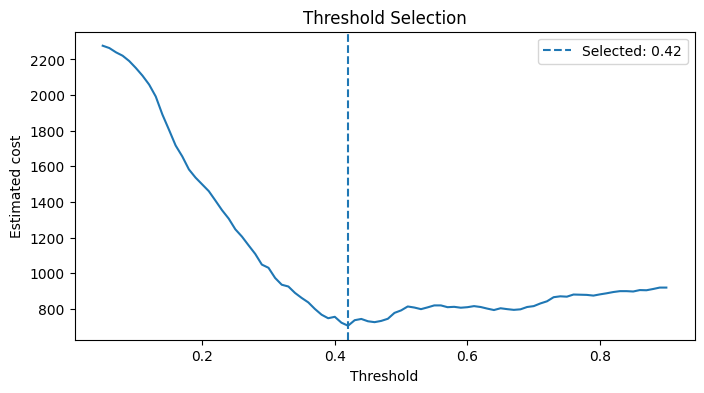

In [ ]:
plt.figure(figsize=(8,4)); plt.plot(costs.threshold,costs.cost)
plt.axvline(best_threshold,linestyle='--',label=f'Selected: {best_threshold:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Estimated cost'); plt.title('Threshold Selection'); plt.legend(); plt.show()

## 14. Final Test Evaluation

In [ ]:
test_p=best_model.predict_proba(X_test_fe)[:,1]
pd.DataFrame([evaluate(y_test,test_p,0.5),evaluate(y_test,test_p,best_threshold)],
             index=['threshold_0.50',f'threshold_{best_threshold:.2f}'])

,roc_auc,pr_auc,accuracy,precision,recall,f1
threshold_0.50,0.714404,0.184639,0.903750,0.198953,0.327586,0.247557
threshold_0.42,0.714404,0.184639,0.851667,0.140719,0.405172,0.208889


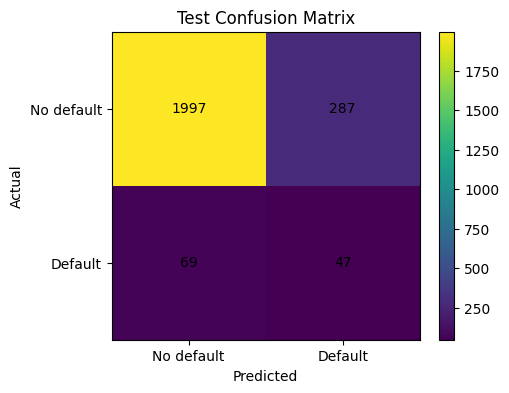

              precision    recall  f1-score   support

  No default       0.97      0.87      0.92      2284
     Default       0.14      0.41      0.21       116

    accuracy                           0.85      2400
   macro avg       0.55      0.64      0.56      2400
weighted avg       0.93      0.85      0.88      2400



In [ ]:
test_pred=(test_p>=best_threshold).astype(int)
cm=confusion_matrix(y_test,test_pred)
plt.figure(figsize=(5,4)); plt.imshow(cm); plt.colorbar(); plt.xticks([0,1],['No default','Default']); plt.yticks([0,1],['No default','Default'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Test Confusion Matrix')
for i in range(2):
    for j in range(2): plt.text(j,i,str(cm[i,j]),ha='center',va='center')
plt.show(); print(classification_report(y_test,test_pred,target_names=['No default','Default']))

## 15. Calibration

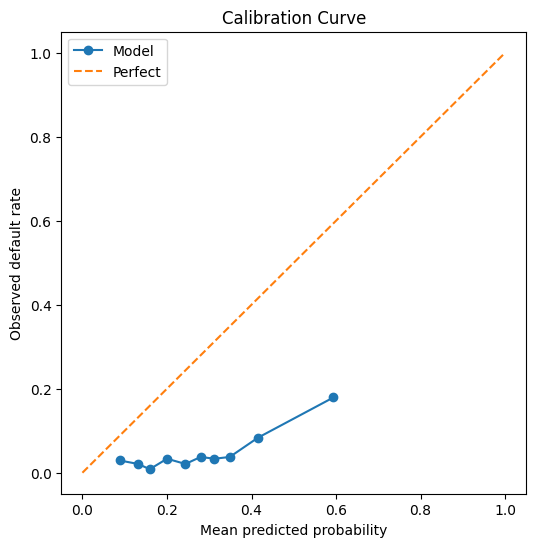

In [ ]:
observed,predicted=calibration_curve(y_test,test_p,n_bins=10,strategy='quantile')
plt.figure(figsize=(6,6)); plt.plot(predicted,observed,marker='o',label='Model'); plt.plot([0,1],[0,1],linestyle='--',label='Perfect')
plt.xlabel('Mean predicted probability'); plt.ylabel('Observed default rate'); plt.title('Calibration Curve'); plt.legend(); plt.show()

## 16. Global Interpretability

In [ ]:
pi=permutation_importance(best_model,X_valid_fe,y_valid,scoring='roc_auc',n_repeats=8,random_state=SEED,n_jobs=-1)
importance=pd.DataFrame({'feature':X_valid_fe.columns,'importance':pi.importances_mean,'std':pi.importances_std}).sort_values('importance',ascending=False)
importance.head(15)

,feature,importance,std
15,credit_stress_index,0.051068,0.007626
3,revolving_utilization,0.019308,0.006765
13,total_delinquencies,0.012966,0.005128
10,payment_ratio_6m,0.008570,0.002774
0,age,0.005789,0.001838
8,late_60_89,0.005699,0.001984
4,debt_ratio,0.004016,0.001030
17,income_per_dependent,0.003133,0.004481
14,has_severe_delinquency,0.002173,0.000506
9,late_90_plus,0.001839,0.000590


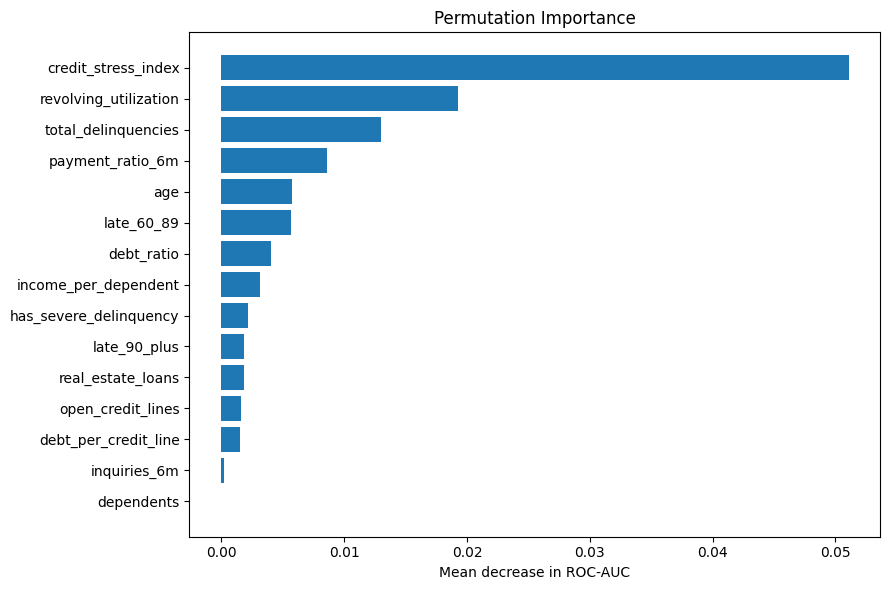

In [ ]:
top=importance.head(15).sort_values('importance')
plt.figure(figsize=(9,6)); plt.barh(top.feature,top.importance); plt.xlabel('Mean decrease in ROC-AUC'); plt.title('Permutation Importance'); plt.tight_layout(); plt.show()

## 17. Local Explanation

Each feature is replaced with its training median, one at a time, to estimate its local influence. This is an associative approximation, not a causal explanation.

In [ ]:
medians=X_train_fe.median(numeric_only=True)
def local_explanation(model,row,baselines):
    original=model.predict_proba(row)[:,1][0]; rows=[]
    for feature in row.columns:
        changed=row.copy(); changed.loc[:,feature]=baselines[feature]
        altered=model.predict_proba(changed)[:,1][0]
        rows.append({'feature':feature,'observed':row.iloc[0][feature],'baseline':baselines[feature],
                     'risk_contribution':original-altered})
    return pd.DataFrame(rows).sort_values('risk_contribution',key=lambda s:s.abs(),ascending=False),original

idx=int(np.argmax(test_p)); explanation,prob=local_explanation(best_model,X_test_fe.iloc[[idx]],medians)
print('Predicted probability:',round(prob,4)); explanation.head(12)

Predicted probability: 0.9167


,feature,observed,baseline,risk_contribution
15,credit_stress_index,2.382829,0.135794,0.243387
13,total_delinquencies,4.000000,0.000000,0.192542
10,payment_ratio_6m,0.310897,0.795450,0.184968
3,revolving_utilization,0.824500,0.328400,0.166542
7,late_30_59,2.000000,0.000000,0.095217
8,late_60_89,2.000000,0.000000,0.031744
4,debt_ratio,0.898500,0.360650,0.009566
16,debt_per_credit_line,0.128357,0.045896,0.006548
2,dependents,4.000000,1.000000,-0.004411
12,inquiries_6m,3.000000,1.000000,-0.003163


## 18. Risk Bands and Subgroup Diagnostics

In [ ]:
results=X_test.copy(); results['actual']=y_test.values; results['probability']=test_p
results['risk_band']=pd.cut(results.probability,[-np.inf,0.10,0.25,0.50,np.inf],labels=['Low','Moderate','High','Very High'])
results.groupby('risk_band',observed=False).agg(borrowers=('actual','size'),average_risk=('probability','mean'),observed_default_rate=('actual','mean'))

,borrowers,average_risk,observed_default_rate
risk_band,,,
Low,157,0.077097,0.031847
Moderate,951,0.170269,0.023134
High,1101,0.338348,0.046322
Very High,191,0.622294,0.198953


In [ ]:
diag=X_test.copy(); diag['actual']=y_test.values; diag['probability']=test_p; diag['prediction']=test_pred
diag['age_group']=pd.cut(diag.age,[17,30,45,60,100],labels=['18-30','31-45','46-60','61+'])
rows=[]
for group,s in diag.groupby('age_group',observed=False):
    if len(s)>0 and s.actual.nunique()>1:
        rows.append({'age_group':str(group),'borrowers':len(s),'default_rate':s.actual.mean(),
                     'roc_auc':roc_auc_score(s.actual,s.probability),
                     'precision':precision_score(s.actual,s.prediction,zero_division=0),
                     'recall':recall_score(s.actual,s.prediction,zero_division=0)})
pd.DataFrame(rows)

,age_group,borrowers,default_rate,roc_auc,precision,recall
0,18-30,247,0.064777,0.712392,0.195122,0.500000
1,31-45,925,0.043243,0.750989,0.111111,0.450000
2,46-60,914,0.055799,0.706882,0.166667,0.372549
3,61+,314,0.028662,0.553734,0.117647,0.222222


## 19. Save the Model and Build an Inference Function

In [ ]:
joblib.dump(best_model,'credit_default_model.joblib')
metadata={'threshold':best_threshold,'feature_columns':X_train_fe.columns.tolist(),
          'cap_limits':cap_limits,'disclaimer':'Synthetic educational model; not for lending decisions.'}
Path('credit_default_model_metadata.json').write_text(json.dumps(metadata,indent=2))
print('Saved model and metadata')

Saved model and metadata


In [ ]:
def predict_default_risk(raw_borrower,model_path='credit_default_model.joblib',metadata_path='credit_default_model_metadata.json'):
    model=joblib.load(model_path); metadata=json.loads(Path(metadata_path).read_text())
    limits={k:tuple(v) for k,v in metadata['cap_limits'].items()}
    engineered=engineer_features(raw_borrower,limits)[metadata['feature_columns']]
    p=model.predict_proba(engineered)[:,1]
    result=raw_borrower.copy(); result['predicted_default_probability']=p
    result['predicted_default_flag']=(p>=metadata['threshold']).astype(int)
    return result

predict_default_risk(X_test.iloc[[0]])

,age,monthly_income,dependents,revolving_utilization,debt_ratio,open_credit_lines,real_estate_loans,late_30_59,late_60_89,late_90_plus,payment_ratio_6m,credit_history_years,inquiries_6m,predicted_default_probability,predicted_default_flag
6239,39,8510.49,2.0,0.4741,0.2026,6,0,0,0,0,0.7958,5.3,1,0.291017,0


## 20. Business Recommendations and Limitations

Potential actions include normal servicing for low-risk accounts, educational reminders for moderate risk, hardship outreach for high risk, and controlled manual review for very high risk.

Before production, the model would require real governed data, temporal validation, calibration review, legal and compliance review, bias testing, documentation, monitoring, and human oversight.

## 21. Portfolio Summary

### GitHub description

Built an end-to-end credit-default prediction system using synthetic borrower data and scikit-learn. Compared logistic regression, random forest, gradient boosting, and neural-network models. Added feature engineering, imbalance handling, cross-validation, business-cost threshold optimization, calibration, permutation importance, local explanations, risk bands, subgroup diagnostics, persistence, and inference.

### Resume bullets

- Developed a machine-learning pipeline to estimate 24-month credit-default risk from utilization, debt burden, income, and delinquency history.
- Compared four classification approaches using ROC-AUC, PR-AUC, precision, recall, and F1.
- Implemented leakage-safe imputation, outlier capping, Yeo-Johnson transformation, scaling, and engineered credit-risk features.
- Tuned a class-weighted random forest with stratified cross-validation and optimized its threshold using asymmetric business costs.
- Added global and local interpretability, probability calibration, risk segmentation, subgroup diagnostics, and reusable inference.

## 22. Interview Questions

**Why not use accuracy alone?** Default is often rare, so a majority-class model may look accurate while missing risky accounts.

**Why stratify the split?** It preserves the event rate across train, validation, and test sets.

**Why fit preprocessing only on training data?** Using validation or test information causes leakage.

**Why optimize the threshold separately?** Probability estimation and operational decision policy are separate problems.

**Why evaluate calibration?** Good ranking does not guarantee that predicted probabilities match observed risk.

**What would you improve next?** Add out-of-time validation, approved real data, stronger boosting libraries, stability analysis, formal fairness review, and regulatory model-risk documentation.

## 23. Conclusion

This notebook demonstrates the complete lifecycle of a credit-default classification project while remaining self-contained and portfolio-ready. Because the dataset is synthetic, results demonstrate technical capability rather than real-world lending validity.